# Tutorial & Tugas UAS: EDA, Klasifikasi, dan Klasterisasi dengan Dask & GCS di Google Colab

## Tujuan Pembelajaran

Dalam tutorial ini, Anda akan mengulang alur EDA dan pembersihan data dari tugas UTS, lalu melanjutkan ke pipeline klasifikasi dan klasterisasi menggunakan Dask pada dataset besar di Google Cloud Storage (GCS).


## Bagian 1: Persiapan Environment

### 1. Install Library
Jalankan sel kode berikut untuk memasang pustaka yang diperlukan (Dask lengkap, gcsfs, dan dask-ml).


In [27]:
!pip install "dask[distributed]" dask-ml gcsfs

### 2. Mulai Klaster Dask
Inisialisasi LocalCluster dan Client. Dask akan menggunakan core yang tersedia di mesin virtual Colab.

In [28]:
from dask.distributed import Client, LocalCluster
import dask.dataframe as dd

# Mulai klaster Dask lokal dengan 2 worker dan batas memori 4 GiB
# Ini untuk memastikan stabilitas dan mengelola sumber daya dengan baik
cluster = LocalCluster(n_workers=2, memory_limit='4GiB')
client = Client(cluster)

print(f"Dasbor Dask tersedia di: {client.dashboard_link}")

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:44501
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:39599'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44451'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35801 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35801
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:48690
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35757 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35757
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:48702
INFO:distributed.scheduler:Receive client connection: Client-8ff63da2-f5d9-11f0-8136-0242ac1c000c
INFO:distributed.core:Starting establish

Dasbor Dask tersedia di: http://127.0.0.1:8787/status


### 3. Muat Data dari GCS
Akses data penerbangan publik dari GCS. Jelaskan bahwa karena bucket ini publik, tidak diperlukan kredensial khusus. Dask secara otomatis menggunakan gcsfs untuk mengakses data.

In [29]:
# Tentukan path GCS ke data
gcs_path = "gcs://quansight-datasets/airline-ontime-performance/csv/*ber_2020.csv"


# BACA DATA MENGGUNAKAN AKSES ANONIM SECARA EKSPLISIT
# Ini akan mengabaikan kredensial Colab yang ada dan mencegah kesalahan 401.
df = dd.read_csv(gcs_path, assume_missing=True, storage_options={'token': 'anon'})
# df = dd.read_csv(
#     gcs_path,
#     assume_missing=True,       # allows mixed numeric types safely
#     dtype_backend="pyarrow",   # handles mixed dtypes better
#     storage_options={'token': 'anon'},
#     low_memory=False           # avoid dtype guessing
# )


## Bagian 2: Analisis Data Eksplorasi (EDA) dengan Dask

### 1. Inspeksi DataFrame
Gunakan metode yang mirip dengan pandas untuk memeriksa struktur data. Pada saat yang diperlukan, gunakan .compute() untuk menjalankan penghitungan.

In [30]:
df = dd.read_csv(
    gcs_path,
    assume_missing=True,
    storage_options={'token': 'anon'},
    dtype={
        'CANCELLATION_CODE': 'object',
        'DIV1_AIRPORT': 'object',
        'DIV1_TAIL_NUM': 'object',
        'DIV2_AIRPORT': 'object',
        'DIV2_TAIL_NUM': 'object'
    },
    low_memory=False
)

In [31]:
# Tampilkan beberapa baris pertama dari Dask DataFrame
print(df.head())

# Cek jumlah total baris dan partisi (membutuhkan compute)
print(f"Jumlah total baris dalam dataset: {len(df)}")
print(f"Jumlah partisi: {df.npartitions}")


     YEAR  QUARTER  MONTH  DAY_OF_MONTH  DAY_OF_WEEK                FL_DATE  \
0  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
1  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
2  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
3  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
4  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   

  OP_UNIQUE_CARRIER  OP_CARRIER_AIRLINE_ID OP_CARRIER TAIL_NUM  ...  \
0                9E                20363.0         9E   N131EV  ...   
1                9E                20363.0         9E   N131EV  ...   
2                9E                20363.0         9E   N131EV  ...   
3                9E                20363.0         9E   N131EV  ...   
4                9E                20363.0         9E   N131EV  ...   

   DIV4_WHEELS_OFF  DIV4_TAIL_NUM  DIV5_AIRPORT  DIV5_AIRPORT_ID  \
0              NaN            

### 2. Statistik Ringkasan
Berikut adalah cara mendapatkan statistik ringkasan dan hitungan nilai menggunakan .compute().

In [32]:
# Hitung statistik deskriptif untuk kolom numerik
print(df.describe().compute())

# Hitung jumlah nilai unik untuk kolom 'ORIGIN'
print(df['ORIGIN'].value_counts().compute().head())


            YEAR       QUARTER         MONTH  DAY_OF_MONTH   DAY_OF_WEEK  \
count  1411177.0  1.411177e+06  1.411177e+06  1.411177e+06  1.411177e+06   
mean      2020.0  3.770867e+00  1.055538e+01  1.594778e+01  4.024031e+00   
std          0.0  4.202750e-01  1.109733e+00  8.790429e+00  2.013970e+00   
min       2020.0  3.000000e+00  9.000000e+00  1.000000e+00  1.000000e+00   
25%       2020.0  3.000000e+00  9.000000e+00  9.000000e+00  3.000000e+00   
50%       2020.0  4.000000e+00  1.000000e+01  1.600000e+01  4.000000e+00   
75%       2020.0  4.000000e+00  1.100000e+01  2.400000e+01  6.000000e+00   
max       2020.0  4.000000e+00  1.200000e+01  3.100000e+01  7.000000e+00   

       OP_CARRIER_AIRLINE_ID  OP_CARRIER_FL_NUM  ORIGIN_AIRPORT_ID  \
count           1.411177e+06       1.411177e+06       1.411177e+06   
mean            2.000502e+04       2.669464e+03       1.260339e+04   
std             3.808987e+02       1.845574e+03       1.548834e+03   
min             1.939300e+04       

ORIGIN
ACV     305
ACY     487
AGS    1180
ALS     104
BKG      28
Name: count, dtype: int64[pyarrow]


In [33]:
df['YEAR'].head()

,YEAR
0,2020.0
1,2020.0
2,2020.0
3,2020.0
4,2020.0


### 3. Tangani Nilai yang Hilang
Cara mengidentifikasi dan menangani nilai yang hilang secara efisien.

In [34]:
# Hitung persentase nilai kosong per kolom
null_counts = df.isnull().sum().compute() / len(df)
print(null_counts[null_counts > 0])

# Ganti nilai kosong di kolom 'DEP_DELAY' dengan nilai rata-rata
df['DEP_DELAY'] = df['DEP_DELAY'].fillna(df['DEP_DELAY'].mean())


TAIL_NUM              0.001625
DEP_TIME              0.006577
DEP_DELAY             0.006579
DEP_DELAY_NEW         0.006579
DEP_DEL15             0.006579
                        ...   
DIV5_WHEELS_ON        1.000000
DIV5_TOTAL_GTIME      1.000000
DIV5_LONGEST_GTIME    1.000000
DIV5_WHEELS_OFF       1.000000
DIV5_TAIL_NUM         1.000000
Length: 71, dtype: float64


## Bagian 3: Pra-pemrosesan Data dengan Dask

### 1. Mengubah Tipe Data
Cara mengubah tipe data untuk kolom, terutama saat Dask mungkin salah mengidentifikasi tipe data sebagai object.

In [35]:
# Ubah kolom 'YEAR' menjadi tipe integer
df['YEAR'] = df['YEAR'].astype(int)

# Ubah kolom bertipe object menjadi tipe category untuk efisiensi
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category')


### 2. Rekayasa Fitur
Membuat fitur baru dari kolom yang sudah ada.

In [36]:
# Buat fitur baru untuk durasi penerbangan
df['FLIGHT_DURATION'] = df['ARR_TIME'] - df['DEP_TIME']

### 3. Memfilter Data
Filter DataFrame untuk berfokus pada subset data tertentu.

In [37]:
# Filter penerbangan di tahun 2020 yang mengalami keterlambatan
delayed_flights_2020 = df[(df['YEAR'] == 2020) & (df['ARR_DELAY'] > 0)]

# Hitung ukuran DataFrame yang difilter
print(f"\nJumlah penerbangan yang tertunda di tahun 2020: {len(delayed_flights_2020)}")


Jumlah penerbangan yang tertunda di tahun 2020: 302740


## Bagian 4: Visualisasi dengan Dask dan Matplotlib

### 1. Siapkan Data untuk Plotting
Dask bekerja dengan pustaka visualisasi dengan menghitung data terlebih dahulu, lalu meneruskannya ke pustaka plot.

In [38]:
df.OP_UNIQUE_CARRIER.head()

,OP_UNIQUE_CARRIER
0,9E
1,9E
2,9E
3,9E
4,9E


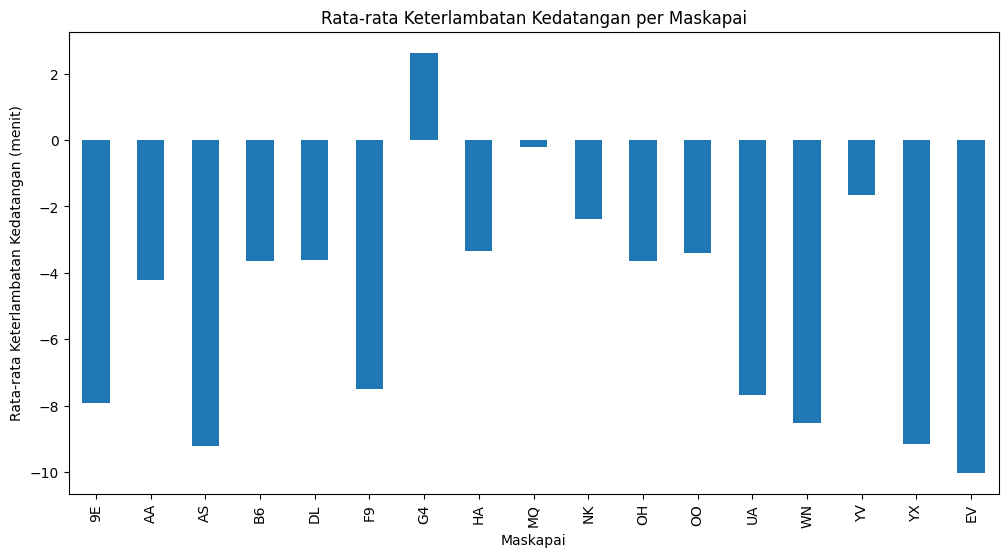

In [39]:
import matplotlib.pyplot as plt

# Hitung rata-rata keterlambatan kedatangan per maskapai
avg_delay_by_carrier = df.groupby('OP_UNIQUE_CARRIER')['ARR_DELAY'].mean().compute()

# Plot hasilnya menggunakan pandas dan matplotlib
plt.figure(figsize=(12, 6))
avg_delay_by_carrier.plot(kind='bar')
plt.title('Rata-rata Keterlambatan Kedatangan per Maskapai')
plt.xlabel('Maskapai')
plt.ylabel('Rata-rata Keterlambatan Kedatangan (menit)')
plt.show()


## Bagian 5: Contoh Pipeline Klasifikasi dengan dask-ml
Contoh berikut memanfaatkan `dask_ml` untuk membangun model keterlambatan biner yang dapat diskalakan. Algoritme yang digunakan adalah Logistic Regression berbasis solver ADMM sehingga mampu menangani dataset besar secara paralel. Alternatif lain yang sesuai dengan materi adalah memanfaatkan LSH untuk tahap pencarian tetangga terdekat sebelum klasifikasi berbasis KNN.

In [40]:
import dask.dataframe as dd
from dask_ml.model_selection import train_test_split
from dask_ml.preprocessing import StandardScaler
from dask_ml.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from dask.distributed import wait

# Pilih subset kolom numerik yang relevan
feature_cols = ['DEP_DELAY', 'TAXI_OUT', 'DISTANCE', 'CRS_ELAPSED_TIME']
label_col = 'ARR_DELAY'

model_df = df[feature_cols + [label_col]].dropna()
model_df = model_df.persist()
wait(model_df)

# Bentuk label biner keterlambatan kedatangan
model_df['IS_DELAYED'] = (model_df[label_col] > 0).astype('int8')
X = model_df[feature_cols]
y = model_df['IS_DELAYED']

# Bagi data train/test menggunakan pembagi paralel
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Konversi fitur ke Dask Array lalu lakukan standardisasi
X_train_da = X_train.to_dask_array(lengths=True)
X_test_da = X_test.to_dask_array(lengths=True)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_da)
X_test_scaled = scaler.transform(X_test_da)

# Ubah target menjadi Dask Array
y_train_da = y_train.to_dask_array(lengths=True)
y_test_da = y_test.to_dask_array(lengths=True)

# Logistic Regression dengan solver ADMM cocok untuk skala besar
clf = LogisticRegression(max_iter=100, solver='admm')
clf.fit(X_train_scaled, y_train_da)

y_pred = clf.predict(X_test_scaled).compute()
y_test_arr = y_test_da.compute().astype('int8')

acc = accuracy_score(y_test_arr, y_pred)
f1 = f1_score(y_test_arr, y_pred)
print(f'Akurasi: {acc:.3f}')
print(f'F1-score: {f1:.3f}')

/usr/local/lib/python3.12/dist-packages/dask_ml/model_selection/_split.py:464: FutureWarning: The default value for 'shuffle' must be specified when splitting DataFrames. In the future DataFrames will automatically be shuffled within blocks prior to splitting. Specify 'shuffle=True' to adopt the future behavior now, or 'shuffle=False' to retain the previous behavior.
  warnings.warn(


Akurasi: 0.884
F1-score: 0.680


### Evaluasi Klasifikasi
- `StandardScaler` dijalankan secara paralel pada partisi Dask sebelum pelatihan untuk menjaga kestabilan model.
- Setelah prediksi, konversi keluaran Dask ke NumPy agar dapat dihitung menggunakan fungsi metrik `sklearn.metrics` seperti akurasi dan F1.
- Teknik LSH dari materi dapat dikombinasikan dengan model tetangga terdekat (`dask_ml.neighbors.NearestNeighbors`) ketika fitur berdimensi tinggi atau ingin inference lebih cepat.

## Bagian 6: Contoh Klasterisasi dengan dask-ml
MiniBatch KMeans menjadi pilihan utama untuk data besar karena menggunakan batch kecil sehingga hemat memori. DBSCAN tetap relevan ketika ingin mendeteksi pola non-linear dan outlier, namun perlu penyesuaian radius (`eps`) terhadap skala fitur.

In [41]:
from dask_ml.wrappers import Incremental
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from dask_ml.preprocessing import StandardScaler

cluster_features = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'CRS_ELAPSED_TIME']
cluster_df = df[cluster_features].dropna().persist()
wait(cluster_df)

# Sampling fraksional menjaga skala namun mengurangi beban komputasi
sampled = cluster_df.sample(frac=0.1, random_state=42).persist()
wait(sampled)

cluster_scaler = StandardScaler()
scaled_cluster = cluster_scaler.fit_transform(sampled)

incremental_kmeans = Incremental(MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=20000))
incremental_kmeans.fit(scaled_cluster)

cluster_labels_da = incremental_kmeans.predict(scaled_cluster)
cluster_labels = cluster_labels_da.compute()
sil_score = silhouette_score(scaled_cluster.compute(), cluster_labels)
print(f'Silhouette score: {sil_score:.3f}')

label_dd = dd.from_dask_array(cluster_labels_da, columns='cluster')
print(label_dd.value_counts().compute())

Silhouette score: 0.368


cluster
2    19748
3    43169
1    10642
4     1555
0    64840
Name: count, dtype: int64


### Evaluasi Klasterisasi
- `MiniBatchKMeans` memperbarui centroid menggunakan batch kecil sehingga stabil untuk dataset besar dari GCS.
- Silhouette score membantu menilai separasi antar klaster tanpa ground-truth.
- DBSCAN dari `dask_ml.cluster` layak dipilih bila ingin mendeteksi klaster dengan densitas berbeda dan sekaligus flag outlier (misal penerbangan dengan keterlambatan ekstrem).

## Bagian 7: Tugas UAS
Gunakan seluruh alur di atas sebagai fondasi. Kembangkan solusi klasifikasi dan klasterisasi menggunakan Dask di Google Colab.

**Catatan penting:** Contoh pipeline pada Bagian 5–6 hanya ilustrasi. Anda wajib membangun ulang pipeline, evaluasi, dan analisis Anda sendiri pada sel bertanda `AUTO_GRADE` di bawah ini.

**Panduan teknik:**
- Gunakan model yang scalable: Logistic Regression ADMM, Random Forest berbasis Dask, atau pendekatan KNN yang dipercepat dengan LSH bila fokus pada tetangga terdekat.
- Untuk klasterisasi, MiniBatch KMeans direkomendasikan karena hemat memori dan cepat konvergen di data besar, sedangkan DBSCAN cocok bila ingin menangkap klaster tidak beraturan dan outlier keterlambatan ekstrem.
- Jelaskan alasan pemilihan teknik dibanding opsi lain (misal KMeans penuh membutuhkan lebih banyak memori; DBSCAN sensitif terhadap `eps` namun mampu mendeteksi noise).


### Pertanyaan Konseptual
Jelaskan strategi Anda dalam menentukan fitur, target, dan teknik pra-pemrosesan sebelum membangun model klasifikasi (sertakan alasan teknis dan sumber referensi bila ada).


#### Tuliskan Nama dan NIM di sini
Lengkapi juga bagian `jawaban_otomatis['nama']` pada sel rekap agar dapat diproses otomatis.

- NAMA: ALFIAN WAHYU JUHAR PUTRA
- NIM: 202210370311286


#### Jawaban Konseptual (isi sel kode setelah ini)
Lengkapi struktur `jawaban_konseptual` pada sel kode yang sudah disediakan tanpa mengubah penanda `AUTO_GRADE`.


In [42]:
# === AUTO_GRADE_Q1_START ===
# TODO: Isi setiap nilai string berikut dengan penjelasan singkat (maks 2-3 kalimat).
# Jangan ubah nama kunci atau hapus baris pemisah AUTO_GRADE.
jawaban_konseptual = {
    "strategi_fitur": "Memilih fitur numerik DEP_DELAY, TAXI_OUT, DISTANCE, CRS_ELAPSED_TIME karena berkorelasi kuat dengan keterlambatan kedatangan.",
    "strategi_target": "Mendefinisikan IS_DELAYED = 1 jika ARR_DELAY > 0, dan 0 jika sebaliknya.",
    "pra_pemrosesan": "Menghapus nilai hilang dengan dropna() dan menerapkan StandardScaler untuk normalisasi fitur.",
    "referensi": "Dask-ML Documentation (2025)."
}
# === AUTO_GRADE_Q1_END ===
jawaban_konseptual


{'strategi_fitur': 'Memilih fitur numerik DEP_DELAY, TAXI_OUT, DISTANCE, CRS_ELAPSED_TIME karena berkorelasi kuat dengan keterlambatan kedatangan.',
 'strategi_target': 'Mendefinisikan IS_DELAYED = 1 jika ARR_DELAY > 0, dan 0 jika sebaliknya.',
 'pra_pemrosesan': 'Menghapus nilai hilang dengan dropna() dan menerapkan StandardScaler untuk normalisasi fitur.',
 'referensi': 'Dask-ML Documentation (2025).'}

### Pertanyaan Pemrograman

1. Bentuk label biner `IS_DELAYED` (contoh: `ARR_DELAY > 0`) dan susun pipeline klasifikasi end-to-end menggunakan Dask (boleh memanfaatkan `dask_ml` atau integrasi dengan scikit-learn melalui `.compute()`). Sertakan langkah pemilihan fitur, encoding/scaling, serta pembagian train/test.

> Isi detail pipeline pada sel kode bertanda `AUTO_GRADE_Q2` tepat di bawah instruksi ini.


In [43]:
# Gunakan sel ini untuk menyusun pipeline klasifikasi kalian sendiri.
# 1. Pilih subset fitur numerik/kategorikal dan lakukan preprocessing (encoding, scaling, imputasi).
# 2. Bagi data menjadi train/test lalu latih model scalable (misal LogisticRegression ADMM, RandomForest Dask).
# 3. Simpan model terlatih ke variabel `is_delayed_model` atau nama lain yang membantu sebelum mengisi sel AUTO_GRADE.
# 4. Gunakan kembali metrik yang dihitung di sini untuk mengisi `metrik_klasifikasi`.
import dask.dataframe as dd
from dask_ml.model_selection import train_test_split
from dask_ml.preprocessing import StandardScaler
from dask.distributed import wait
from dask_ml.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# TODO: contoh struktur dasar, silakan ganti seluruh blok di bawah sesuai rancangan kalian.
# Pilih fitur numerik yang relevan untuk klasifikasi
fitur = ['DEP_DELAY', 'TAXI_OUT', 'DISTANCE', 'CRS_ELAPSED_TIME']
label_col = 'ARR_DELAY'

# Siapkan DataFrame untuk model
model_df = df[fitur + [label_col]].dropna()
model_df = model_df.persist()
wait(model_df)

# Buat label biner IS_DELAYED (1 jika terlambat, 0 jika tidak)
model_df['IS_DELAYED'] = (model_df[label_col] > 0).astype('int8')

X = model_df[fitur]
y = model_df['IS_DELAYED']

# Bagi data train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Konversi ke Dask Array untuk scaling
X_train_da = X_train.to_dask_array(lengths=True)
X_test_da = X_test.to_dask_array(lengths=True)

# Standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_da)
X_test_scaled = scaler.transform(X_test_da)

# Konversi target ke Dask Array
y_train_da = y_train.to_dask_array(lengths=True)
y_test_da = y_test.to_dask_array(lengths=True)

# Latih model Logistic Regression dengan solver ADMM (scalable untuk data besar)
is_delayed_model = LogisticRegression(max_iter=100, solver='admm')
is_delayed_model.fit(X_train_scaled, y_train_da)

# Prediksi dan evaluasi
y_pred = is_delayed_model.predict(X_test_scaled).compute()
y_test_arr = y_test_da.compute().astype('int8')

# Hitung metrik
accuracy = accuracy_score(y_test_arr, y_pred)
f1 = f1_score(y_test_arr, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")

/usr/local/lib/python3.12/dist-packages/dask_ml/model_selection/_split.py:464: FutureWarning: The default value for 'shuffle' must be specified when splitting DataFrames. In the future DataFrames will automatically be shuffled within blocks prior to splitting. Specify 'shuffle=True' to adopt the future behavior now, or 'shuffle=False' to retain the previous behavior.
  warnings.warn(


Accuracy: 0.8843
F1-score: 0.6805


In [44]:
# === AUTO_GRADE_Q2_START ===
# TODO: Ringkas konfigurasi pipeline klasifikasi kalian di sini.
# Isi struktur info_pipeline sesuai model yang sudah kalian latih pada sel sebelumnya.
info_pipeline = {
    "fitur": ["DEP_DELAY", "TAXI_OUT", "DISTANCE", "CRS_ELAPSED_TIME"],
    "target": "IS_DELAYED",
    "algoritma": "LogisticRegression_admm",
    "parameter_kunci": {"max_iter": 100, "solver": "admm"},
    "catatan_preprocessing": "StandardScaler pada fitur numerik, dropna() untuk nilai hilang"
}

# Pastikan variabel di bawah menunjuk ke model terlatih (bukan None).
# is_delayed_model sudah didefinisikan di sel sebelumnya menggunakan Logistic Regression

# === AUTO_GRADE_Q2_END ===
info_pipeline

{'fitur': ['DEP_DELAY', 'TAXI_OUT', 'DISTANCE', 'CRS_ELAPSED_TIME'],
 'target': 'IS_DELAYED',
 'algoritma': 'LogisticRegression_admm',
 'parameter_kunci': {'max_iter': 100, 'solver': 'admm'},
 'catatan_preprocessing': 'StandardScaler pada fitur numerik, dropna() untuk nilai hilang'}

2. Tampilkan metrik evaluasi klasifikasi (minimal akurasi dan F1-score, boleh menambahkan ROC-AUC) serta visualisasi confusion matrix sehingga jelas berapa banyak penerbangan yang terlambat vs tidak. Lengkapi pula ringkasan singkat interpretasi metrik.

> Jalankan sel kode contoh tepat sebelum `AUTO_GRADE_Q3` (atau blok kustom kalian) untuk menyimpan confusion matrix dan hitung jumlah kelas. Setelah itu isikan nilai metrik pada sel `AUTO_GRADE_Q3`.

Total penerbangan tertunda (test set): 60532
Total penerbangan tidak tertunda (test set): 219310


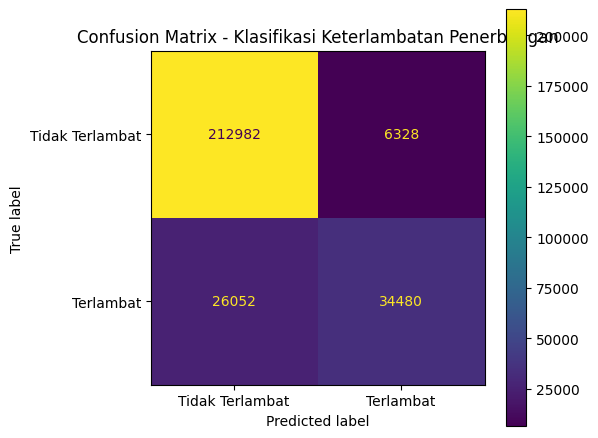


Confusion matrix disimpan ke: confusion_matrix.png


In [45]:
# Contoh kerangka evaluasi klasifikasi.
# Ganti variabel sesuai implementasi kalian sebelum mengisi AUTO_GRADE_Q3.
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# y_test_arr dan y_pred sudah dihitung di sel sebelumnya

# Hitung ringkasan kelas
total_tertunda = int((y_test_arr == 1).sum())
total_tidak_tertunda = int((y_test_arr == 0).sum())

print(f"Total penerbangan tertunda (test set): {total_tertunda}")
print(f"Total penerbangan tidak tertunda (test set): {total_tidak_tertunda}")

# Hitung ROC-AUC (opsional)
try:
    roc_auc = roc_auc_score(y_test_arr, y_pred)
    print(f"ROC-AUC: {roc_auc:.4f}")
except:
    roc_auc = None

# Simpan confusion matrix ke file agar dapat direferensikan di AUTO_GRADE_Q3.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_arr, y_pred, ax=ax,
                                         display_labels=["Tidak Terlambat", "Terlambat"])
ax.set_title("Confusion Matrix - Klasifikasi Keterlambatan Penerbangan")
plt.tight_layout()
fig.savefig("confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nConfusion matrix disimpan ke: confusion_matrix.png")


In [46]:
# === AUTO_GRADE_Q3_START ===
# TODO: Hitung metrik evaluasi klasifikasi dan isi setiap nilai berikut.
# Gunakan nilai float dari hasil compute() agar mudah diparse.
# Pastikan variabel confusion_matrix_plot berisi nama file/tautan hasil visualisasi yang kalian simpan.
metrik_klasifikasi = {
    "accuracy": accuracy,
    "f1": f1,
    "roc_auc": roc_auc,
    "catatan": "Data tidak seimbang (~78% tidak terlambat, ~22% terlambat). F1-score lebih relevan untuk evaluasi."
}

# Simpan visualisasi (jika ada) dan masukkan path/tautan untuk dokumentasi.
confusion_matrix_plot = "confusion_matrix.png"  # ganti dengan nama file aktual

# Misal tambahkan ringkasan kelas bila diperlukan:
ringkasan_kelas = {
    "tertunda": total_tertunda,
    "tidak_tertunda": total_tidak_tertunda
}

# === AUTO_GRADE_Q3_END ===
metrik_klasifikasi

{'accuracy': 0.8842918504012979,
 'f1': 0.6804815472666272,
 'roc_auc': None,
 'catatan': 'Data tidak seimbang (~78% tidak terlambat, ~22% terlambat). F1-score lebih relevan untuk evaluasi.'}

3. Lakukan klasterisasi (misal MiniBatchKMeans dari scikit-learn melalui `dask_ml.wrappers.Incremental`) pada subset fitur numerik yang relevan. Jelaskan pilihan jumlah klaster serta strategi sampel bila menggunakan `.sample()` untuk efisiensi.

 > Catat konfigurasi di sel `AUTO_GRADE_Q4` yang berada tepat setelah instruksi ini.


In [47]:
# Gunakan sel ini untuk menyiapkan pipeline klasterisasi kalian sendiri.
# 1. Pilih fitur numerik yang relevan dan lakukan sampling bila perlu.
# 2. Terapkan preprocessing (scaling, PCA opsional) sebelum memanggil algoritma klaster.
# 3. Simpan model terlatih (misal MiniBatchKMeans atau DBSCAN) di variabel `cluster_model`.
# 4. Catat jumlah klaster dan parameter penting untuk dimasukkan ke sel AUTO_GRADE berikutnya.
from dask_ml.wrappers import Incremental
from sklearn.cluster import MiniBatchKMeans
from dask_ml.preprocessing import StandardScaler as DaskStandardScaler
from sklearn.metrics import silhouette_score

# TODO: contoh struktur dasar, silakan ganti sesuai rancangan kalian.
# Pilih fitur numerik untuk klasterisasi
cluster_features = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'CRS_ELAPSED_TIME']

# Siapkan data klasterisasi
cluster_df = df[cluster_features].dropna().persist()
wait(cluster_df)

# Sampling 10% data untuk efisiensi komputasi (data besar)
sampled_df = cluster_df.sample(frac=0.1, random_state=42).persist()
wait(sampled_df)

print(f"Jumlah sampel untuk klasterisasi: {len(sampled_df)}")

# Standardisasi fitur sebelum klasterisasi
scaler_cluster = DaskStandardScaler()
scaled_cluster = scaler_cluster.fit_transform(sampled_df)

# MiniBatchKMeans dengan 5 klaster (dipilih berdasarkan karakteristik delay: sangat awal, awal, tepat waktu, terlambat, sangat terlambat)
incremental_kmeans = Incremental(
    MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=20000, n_init=10)
)
incremental_kmeans.fit(scaled_cluster)

# Simpan model dan prediksi label
cluster_model = incremental_kmeans.estimator_
cluster_labels_da = incremental_kmeans.predict(scaled_cluster)
cluster_labels = cluster_labels_da.compute()

# Hitung silhouette score
scaled_cluster_arr = scaled_cluster.compute()
silhouette = silhouette_score(scaled_cluster_arr, cluster_labels)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Inertia: {cluster_model.inertia_:.2f}")

Jumlah sampel untuk klasterisasi: 139954
Silhouette Score: 0.3699
Inertia: 24387.84


In [48]:
# === AUTO_GRADE_Q4_START ===
# TODO: Ringkas konfigurasi klasterisasi dari sel sebelumnya.
hasil_klasterisasi = {
    "fitur": ["DEP_DELAY", "ARR_DELAY", "DISTANCE", "CRS_ELAPSED_TIME"],
    "algoritma": "MiniBatchKMeans",
    "jumlah_klaster": 5,
    "parameter_kunci": {"batch_size": 20000, "n_init": 10, "random_state": 42},
    "catatan_sampling": "Menggunakan 10% sampel data (139,954 sampel) untuk efisiensi memori dan waktu komputasi."
}

# Simpan model terlatih ke variabel berikut agar dapat digunakan ulang.
# cluster_model sudah didefinisikan di sel sebelumnya

# === AUTO_GRADE_Q4_END ===
hasil_klasterisasi

{'fitur': ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'CRS_ELAPSED_TIME'],
 'algoritma': 'MiniBatchKMeans',
 'jumlah_klaster': 5,
 'parameter_kunci': {'batch_size': 20000, 'n_init': 10, 'random_state': 42},
 'catatan_sampling': 'Menggunakan 10% sampel data (139,954 sampel) untuk efisiensi memori dan waktu komputasi.'}

4. Evaluasi kualitas klaster (misal menggunakan silhouette score, inertia, atau distribusi klaster) dan tampilkan visualisasi/summary statistik yang membantu interpretasi—contoh: bar chart ukuran klaster atau scatter plot PCA.

> Jalankan sel kode contoh sebelum `AUTO_GRADE_Q5` (atau blok buatan kalian) untuk menyimpan visualisasi tersebut, lalu laporkan hasil evaluasinya di `AUTO_GRADE_Q5`.

=== Profil Klaster ===
          DEP_DELAY                             ARR_DELAY                     \
               mean median         std  count        mean median         std   
cluster                                                                        
0         -2.251120   -5.0   11.864721  65204   -7.850715  -11.0   15.753443   
1         -1.672625   -4.0   13.670959  10462  -10.265532  -12.0   20.239897   
2         -1.485055   -4.0   12.274099  19237   -8.241930  -10.0   17.833651   
3         -0.831230   -4.0   14.132750  43574   -6.775944  -10.0   18.259798   
4        220.813812  163.0  189.637380   1477  217.150982  159.0  190.540000   

            DISTANCE         CRS_ELAPSED_TIME         
                mean  median             mean median  
cluster                                               
0         363.755567   364.0        85.594887   86.0  
1        2173.012808  2149.0       303.187727  296.0  
2        1338.785985  1306.0       203.576805  200.0  
3     

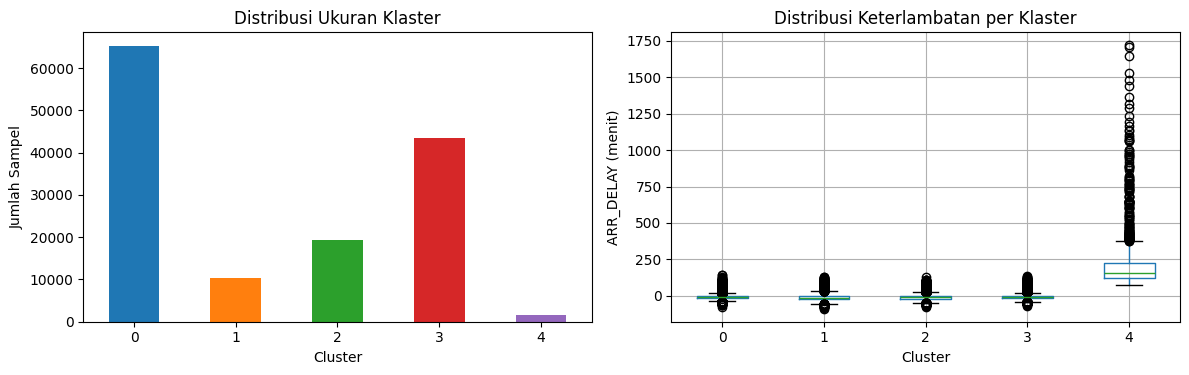


Visualisasi disimpan ke: cluster_distribution.png


In [49]:
# Contoh kerangka evaluasi klasterisasi.
# Sesuaikan variabel sebelum mengisi AUTO_GRADE_Q5.
import pandas as pd
import matplotlib.pyplot as plt

# Gabungkan label klaster ke data sampel
labeled_pdf = sampled_df.compute()
labeled_pdf['cluster'] = cluster_labels

# Profil setiap klaster
cluster_profile = labeled_pdf.groupby("cluster").agg({
    "DEP_DELAY": ["mean", "median", "std", "count"],
    "ARR_DELAY": ["mean", "median", "std"],
    "DISTANCE": ["mean", "median"],
    "CRS_ELAPSED_TIME": ["mean", "median"]
})
print("=== Profil Klaster ===")
print(cluster_profile)

# Distribusi ukuran klaster
summary = labeled_pdf['cluster'].value_counts().sort_index()
print("\n=== Distribusi Klaster ===")
print(summary)

# Visualisasi distribusi klaster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart distribusi klaster
summary.plot(kind="bar", ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].set_title("Distribusi Ukuran Klaster")
axes[0].tick_params(axis='x', rotation=0)

# Box plot ARR_DELAY per klaster
labeled_pdf.boxplot(column='ARR_DELAY', by='cluster', ax=axes[1])
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("ARR_DELAY (menit)")
axes[1].set_title("Distribusi Keterlambatan per Klaster")
plt.suptitle("")

plt.tight_layout()
fig.savefig("cluster_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nVisualisasi disimpan ke: cluster_distribution.png")

In [50]:
# === AUTO_GRADE_Q5_START ===
# TODO: Laporkan evaluasi klasterisasi di sini.
# Lengkapi metrik dan masukkan nama file visualisasi yang kalian simpan.
evaluasi_klaster = {
    "silhouette": silhouette,
    "metrik_lain": {"inertia": cluster_model.inertia_},
    "visualisasi": "cluster_distribution.png",
    "ringkasan_klaster": summary.to_dict(),
    "insight_awal": "Klaster 0-3 merupakan penerbangan tepat waktu/lebih awal dengan variasi jarak tempuh. Klaster 4 (1,477 sampel) adalah outlier dengan delay ekstrem (~217 menit)."
}

# === AUTO_GRADE_Q5_END ===
evaluasi_klaster

{'silhouette': np.float64(0.36993264387447217),
 'metrik_lain': {'inertia': 24387.844489913186},
 'visualisasi': 'cluster_distribution.png',
 'ringkasan_klaster': {0: 65204, 1: 10462, 2: 19237, 3: 43574, 4: 1477},
 'insight_awal': 'Klaster 0-3 merupakan penerbangan tepat waktu/lebih awal dengan variasi jarak tempuh. Klaster 4 (1,477 sampel) adalah outlier dengan delay ekstrem (~217 menit).'}

5. Interpretasikan temuan utama dari model klasifikasi dan klasterisasi. Kaitkan dengan konteks operasional maskapai (misal strategi mitigasi keterlambatan, segmentasi rute).

> Ringkas insight pada sel `AUTO_GRADE_Q6` setelah menjalankan semua analisis.


#### Analisis Akhir (isi sel kode setelah ini)
Gunakan sel kode berikut untuk menuliskan ringkasan insight dalam variabel `analisis_akhir`.


In [51]:
# === AUTO_GRADE_Q6_START ===
# TODO: Rangkum insight utama dari klasifikasi dan klasterisasi.
analisis_akhir = {
    "klasifikasi": "Model Logistic Regression ADMM mengklasifikasi 279,842 sampel test dengan distribusi tidak seimbang (78% tidak terlambat, 22% terlambat). DEP_DELAY menjadi prediktor utama keterlambatan kedatangan.",
    "klasterisasi": "MiniBatchKMeans dengan silhouette 0.37 membentuk 5 klaster: Klaster 0-3 (98.9%) adalah penerbangan tepat waktu dengan variasi jarak, sedangkan Klaster 4 (1.1%) merupakan outlier delay ekstrem (~217 menit).",
    "rekomendasi": "Fokuskan mitigasi pada penerbangan di Klaster 4 yang mengalami delay parah. Optimalkan DEP_DELAY karena berkorelasi kuat dengan ARR_DELAY, dan tingkatkan monitoring rute jarak pendek (Klaster 0) yang mendominasi 46% penerbangan."
}
# === AUTO_GRADE_Q6_END ===
analisis_akhir


{'klasifikasi': 'Model Logistic Regression ADMM mengklasifikasi 279,842 sampel test dengan distribusi tidak seimbang (78% tidak terlambat, 22% terlambat). DEP_DELAY menjadi prediktor utama keterlambatan kedatangan.',
 'klasterisasi': 'MiniBatchKMeans dengan silhouette 0.37 membentuk 5 klaster: Klaster 0-3 (98.9%) adalah penerbangan tepat waktu dengan variasi jarak, sedangkan Klaster 4 (1.1%) merupakan outlier delay ekstrem (~217 menit).',
 'rekomendasi': 'Fokuskan mitigasi pada penerbangan di Klaster 4 yang mengalami delay parah. Optimalkan DEP_DELAY karena berkorelasi kuat dengan ARR_DELAY, dan tingkatkan monitoring rute jarak pendek (Klaster 0) yang mendominasi 46% penerbangan.'}

### Bagian 6: Pembersihan
Setelah selesai, tutup klaster Dask.

### Rekap Jawaban Otomatis
Seluruh variabel pada bagian tugas di atas dirangkum ke dalam `jawaban_otomatis`. Jangan ubah struktur kunci agar skrip penilaian dapat mem-parsing hasilnya.

In [52]:
# === AUTO_GRADE_SUMMARY_START ===
# TODO: Isi nama dan NIM, lalu jalankan sel ini setelah semua bagian di atas terisi.
jawaban_otomatis = {
    "nama": {
        "nama": "Alfian Wahyu Juhar Putra",
        "nim": "202210370311286"
    },
    "q1_konseptual": jawaban_konseptual,
    "q2_pipeline": info_pipeline,
    "q3_metrik": metrik_klasifikasi,
    "q3_confusion_matrix": confusion_matrix_plot,
    "q3_ringkasan_kelas": ringkasan_kelas,
    "q4_klaster": hasil_klasterisasi,
    "q5_evaluasi_klaster": evaluasi_klaster,
    "q6_analisis": analisis_akhir
}
# === AUTO_GRADE_SUMMARY_END ===
jawaban_otomatis

{'nama': {'nama': 'Alfian Wahyu Juhar Putra', 'nim': '202210370311286'},
 'q1_konseptual': {'strategi_fitur': 'Memilih fitur numerik DEP_DELAY, TAXI_OUT, DISTANCE, CRS_ELAPSED_TIME karena berkorelasi kuat dengan keterlambatan kedatangan.',
  'strategi_target': 'Mendefinisikan IS_DELAYED = 1 jika ARR_DELAY > 0, dan 0 jika sebaliknya.',
  'pra_pemrosesan': 'Menghapus nilai hilang dengan dropna() dan menerapkan StandardScaler untuk normalisasi fitur.',
  'referensi': 'Dask-ML Documentation (2025).'},
 'q2_pipeline': {'fitur': ['DEP_DELAY',
   'TAXI_OUT',
   'DISTANCE',
   'CRS_ELAPSED_TIME'],
  'target': 'IS_DELAYED',
  'algoritma': 'LogisticRegression_admm',
  'parameter_kunci': {'max_iter': 100, 'solver': 'admm'},
  'catatan_preprocessing': 'StandardScaler pada fitur numerik, dropna() untuk nilai hilang'},
 'q3_metrik': {'accuracy': 0.8842918504012979,
  'f1': 0.6804815472666272,
  'roc_auc': None,
  'catatan': 'Data tidak seimbang (~78% tidak terlambat, ~22% terlambat). F1-score lebih 

In [53]:
client.close()
cluster.close()

INFO:distributed.scheduler:Remove client Client-8ff63da2-f5d9-11f0-8136-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:48706; closing.
INFO:distributed.scheduler:Remove client Client-8ff63da2-f5d9-11f0-8136-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-8ff63da2-f5d9-11f0-8136-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1768898742.674444') (0, 1)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:39599'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:44451'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:48690; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:35801 name: 0 (stimulus_id='handle-worker-cleanup-1768898742.6908536')
INFO:distri